In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

raw_data_path = "/home/mardhav-rayapati/Programming/ML/pytorch/Enveda_CASMI_26/data/raw/train.parquet"
train_file = pd.read_parquet(raw_data_path)

In [ ]:
print("Rows:", len(train_file))

print("Unique SMILES:", train_file["normalized_smiles"].nunique())
print("Unique InChIKeys:", train_file["inchikey"].nunique())
print("Unique InChIKey14:", train_file["inchikey14"].nunique())

In [ ]:
print("\nLibraries:")
print(train_file["ingest_lib"].value_counts())

print("\nIonization modes:")
print(train_file["ionization_mode"].value_counts())

print("\nAdducts:")
print(train_file["adduct"].value_counts())

print("\nInstrument types:")
print(train_file["instrument_type"].value_counts())

In [ ]:
spectra_per_smiles = train_file.groupby(
    "normalized_smiles"
).size()

print(spectra_per_smiles.describe())

In [ ]:
print("\nTop 20 molecules by number of spectra:")
print(
    spectra_per_smiles
    .sort_values(ascending=False)
    .head(20)
)

In [ ]:
print(
    "\nMolecules with exactly 1 spectrum:",
    (spectra_per_smiles == 1).sum()
)

print(
    "Molecules with >10 spectra:",
    (spectra_per_smiles > 10).sum()
)

print(
    "Molecules with >100 spectra:",
    (spectra_per_smiles > 100).sum()
)

In [ ]:
spectra_per_inchikey14 = train_file.groupby(
    "inchikey14"
).size()

print(spectra_per_inchikey14.describe())

In [ ]:
missing = train_file.isna().sum()

print(
    missing[missing > 0]
    .sort_values(ascending=False)
)

In [ ]:
print("\nSpectrum peak count:")
print(train_file["num_peaks"].describe())

In [ ]:
# Inspect the structure of one spectrum

row = train_file.iloc[0]

print("Precursor m/z:")
print(row["precursor_mz"])

print("\nNumber of peaks:")
print(row["num_peaks"])

print("\nm/z values:")
print(row["ms2_mzs"])

print("\nNormalized intensities:")
print(row["ms2_normalized_intensities"])

print("\nIonization mode:")
print(row["ionization_mode"])

print("\nAdduct:")
print(row["adduct"])

print("\nMolecule:")
print(row["normalized_smiles"])

In [ ]:
print("Columns:")
print(train_file.columns.tolist())

print("\nSpectrum column types:")
print(train_file[[
    "ms2_mzs",
    "ms2_normalized_intensities"
]].dtypes)

In [ ]:
def plot_spectrum(row, title=None):
    mz = np.asarray(row["ms2_mzs"])
    intensity = np.asarray(row["ms2_normalized_intensities"])

    plt.figure(figsize=(14, 5))

    plt.vlines(
        mz,
        0,
        intensity,
        linewidth=1
    )

    plt.xlabel("m/z")
    plt.ylabel("Normalized Intensity")
    
    if title:
        plt.title(title)

    plt.xlim(0, mz.max() + 10)
    plt.ylim(0, 1.05)

    plt.show()

plot_spectrum(
    train_file.iloc[0],
    title="Example MS/MS Spectrum"
)

In [ ]:
row = train_file.iloc[0]

mz = np.asarray(row["ms2_mzs"])
intensity = np.asarray(row["ms2_normalized_intensities"])

print("Number of peaks:", len(mz))
print("Minimum m/z:", mz.min())
print("Maximum m/z:", mz.max())

print("Maximum intensity:", intensity.max())
print("Total intensity:", intensity.sum())

print("Base peak m/z:", mz[np.argmax(intensity)])

In [ ]:
def match_peaks(mz1, intensity1, mz2, intensity2, tolerance=0.01):
    """
    Match peaks between two MS/MS spectra.

    Parameters
    ----------
    mz1, intensity1 : array-like
        First spectrum.
    mz2, intensity2 : array-like
        Second spectrum.
    tolerance : float
        Maximum allowed m/z difference for a match.

    Returns
    -------
    matches : list of tuples
        (m/z from spectrum 1,
         intensity from spectrum 1,
         m/z from spectrum 2,
         intensity from spectrum 2,
         m/z difference)
    """

    matches = []

    for i in range(len(mz1)):
        differences = np.abs(mz2 - mz1[i])

        # Find closest peak in spectrum 2
        j = np.argmin(differences)

        # Accept it if it is within the tolerance
        if differences[j] <= tolerance:
            matches.append((
                mz1[i],
                intensity1[i],
                mz2[j],
                intensity2[j],
                differences[j]
            ))

    return matches

spectrum1 = train_file.iloc[0]
spectrum2 = train_file.iloc[1]

mz1 = np.asarray(spectrum1["ms2_mzs"])
intensity1 = np.asarray(spectrum1["ms2_normalized_intensities"])

mz2 = np.asarray(spectrum2["ms2_mzs"])
intensity2 = np.asarray(spectrum2["ms2_normalized_intensities"])

matches = match_peaks(
    mz1,
    intensity1,
    mz2,
    intensity2,
    tolerance=0.01
)

print("Spectrum 1 peaks:", len(mz1))
print("Spectrum 2 peaks:", len(mz2))
print("Matched peaks:", len(matches))

for match in matches[:10]:
    print(match)

In [ ]:
print("Spectrum 1:")
print("  SMILES:", spectrum1["normalized_smiles"])
print("  Precursor:", spectrum1["precursor_mz"])
print("  Adduct:", spectrum1["adduct"])

print("\nSpectrum 2:")
print("  SMILES:", spectrum2["normalized_smiles"])
print("  Precursor:", spectrum2["precursor_mz"])
print("  Adduct:", spectrum2["adduct"])

In [ ]:
# Find a molecule with at least 10 spectra
spectra_per_molecule = (
    train_file.groupby("normalized_smiles")
    .size()
    .sort_values(ascending=False)
)

candidate_molecules = spectra_per_molecule[
    spectra_per_molecule >= 10
]

target_smiles = candidate_molecules.index[0]

same_molecule = train_file[
    train_file["normalized_smiles"] == target_smiles
]

print("Target molecule:")
print(target_smiles)

print("\nNumber of spectra:", len(same_molecule))

display(
    same_molecule[
        [
            "precursor_mz",
            "ionization_mode",
            "adduct",
            "num_peaks"
        ]
    ].head(10)
)

In [ ]:
# Inspect the 1468 spectra for the same molecule

display(
    same_molecule[
        [
            "precursor_mz",
            "ionization_mode",
            "adduct",
            "num_peaks"
        ]
    ].head(20)
)

print("\nUnique ionization modes:")
print(same_molecule["ionization_mode"].value_counts())

print("\nUnique adducts:")
print(same_molecule["adduct"].value_counts().head(20))

print("\nPrecursor m/z range:")
print(
    same_molecule["precursor_mz"].min(),
    "→",
    same_molecule["precursor_mz"].max()
)

print("\nNumber of peaks:")
print(same_molecule["num_peaks"].describe())

In [ ]:
# Select spectra of the same molecule with the same ionization/adduct
comparable = same_molecule[
    (same_molecule["ionization_mode"] == "positive") &
    (same_molecule["adduct"] == "[M+H]+")
].reset_index(drop=True)

print("Comparable spectra:", len(comparable))

display(
    comparable[
        [
            "precursor_mz",
            "ionization_mode",
            "adduct",
            "num_peaks"
        ]
    ].head(10)
)

In [ ]:
spectrum_a = comparable.iloc[0]
spectrum_b = comparable.iloc[1]

mz_a = np.asarray(spectrum_a["ms2_mzs"])
intensity_a = np.asarray(
    spectrum_a["ms2_normalized_intensities"]
)

mz_b = np.asarray(spectrum_b["ms2_mzs"])
intensity_b = np.asarray(
    spectrum_b["ms2_normalized_intensities"]
)

matches = match_peaks(
    mz_a,
    intensity_a,
    mz_b,
    intensity_b,
    tolerance=0.01
)

print("Spectrum A peaks:", len(mz_a))
print("Spectrum B peaks:", len(mz_b))
print("Matched peaks:", len(matches))

print("\nFirst 20 matches:")
for match in matches[:20]:
    print(match)

In [ ]:
# Inspect precursor m/z values for the same molecule and [M+H]+

precursor_counts = (
    comparable["precursor_mz"]
    .round(4)
    .value_counts()
    .sort_index()
)

print("Number of unique precursor m/z values:",
      len(precursor_counts))

display(precursor_counts.head(30))
print("\nMost common precursor m/z values:")
display(
    comparable["precursor_mz"]
    .round(4)
    .value_counts()
    .head(20)
)

In [18]:
# Select two spectra of the same molecule,
# same ionization mode, same adduct, and same precursor m/z

target_precursor = 291.0900

comparable_same_precursor = comparable[
    comparable["precursor_mz"].round(4) == target_precursor
].reset_index(drop=True)

print("Spectra with precursor m/z =", target_precursor)
print("Count:", len(comparable_same_precursor))

display(
    comparable_same_precursor[
        [
            "precursor_mz",
            "ionization_mode",
            "adduct",
            "num_peaks"
        ]
    ].head(10)
)

# Select the first two
spectrum_a = comparable_same_precursor.iloc[0]
spectrum_b = comparable_same_precursor.iloc[1]

mz_a = np.asarray(spectrum_a["ms2_mzs"])
intensity_a = np.asarray(
    spectrum_a["ms2_normalized_intensities"]
)

mz_b = np.asarray(spectrum_b["ms2_mzs"])
intensity_b = np.asarray(
    spectrum_b["ms2_normalized_intensities"]
)

matches = match_peaks(
    mz_a,
    intensity_a,
    mz_b,
    intensity_b,
    tolerance=0.01
)

print("\nSpectrum A peaks:", len(mz_a))
print("Spectrum B peaks:", len(mz_b))
print("Matched peaks:", len(matches))

print("\nFirst 20 matches:")
for match in matches[:20]:
    print(match)

Spectra with precursor m/z = 291.09
Count: 243


,precursor_mz,ionization_mode,adduct,num_peaks
0,291.09,positive,[M+H]+,3119
1,291.09,positive,[M+H]+,23
2,291.09,positive,[M+H]+,4
3,291.09,positive,[M+H]+,36
4,291.09,positive,[M+H]+,15
5,291.09,positive,[M+H]+,5
6,291.09,positive,[M+H]+,18
7,291.09,positive,[M+H]+,19
8,291.09,positive,[M+H]+,2
9,291.09,positive,[M+H]+,12



Spectrum A peaks: 3119
Spectrum B peaks: 23
Matched peaks: 7

First 20 matches:
(np.float64(105.0374), np.float64(0.0006825317940022154), np.float64(105.033), np.float64(0.037), np.float64(0.004400000000003956))
(np.float64(107.0536), np.float64(0.001421284186081508), np.float64(107.049), np.float64(0.011), np.float64(0.004599999999996385))
(np.float64(119.0526), np.float64(0.011401474239988156), np.float64(119.049), np.float64(0.099), np.float64(0.00359999999999161))
(np.float64(123.0472), np.float64(0.527114275643731), np.float64(123.044), np.float64(1.0), np.float64(0.003200000000006753))
(np.float64(139.0425), np.float64(1.0), np.float64(139.039), np.float64(0.038), np.float64(0.003500000000002501))
(np.float64(147.0476), np.float64(0.11843909405506708), np.float64(147.044), np.float64(0.021), np.float64(0.003599999999977399))
(np.float64(150.0399), np.float64(0.00026835293898037877), np.float64(150.046), np.float64(0.086), np.float64(0.006100000000003547))


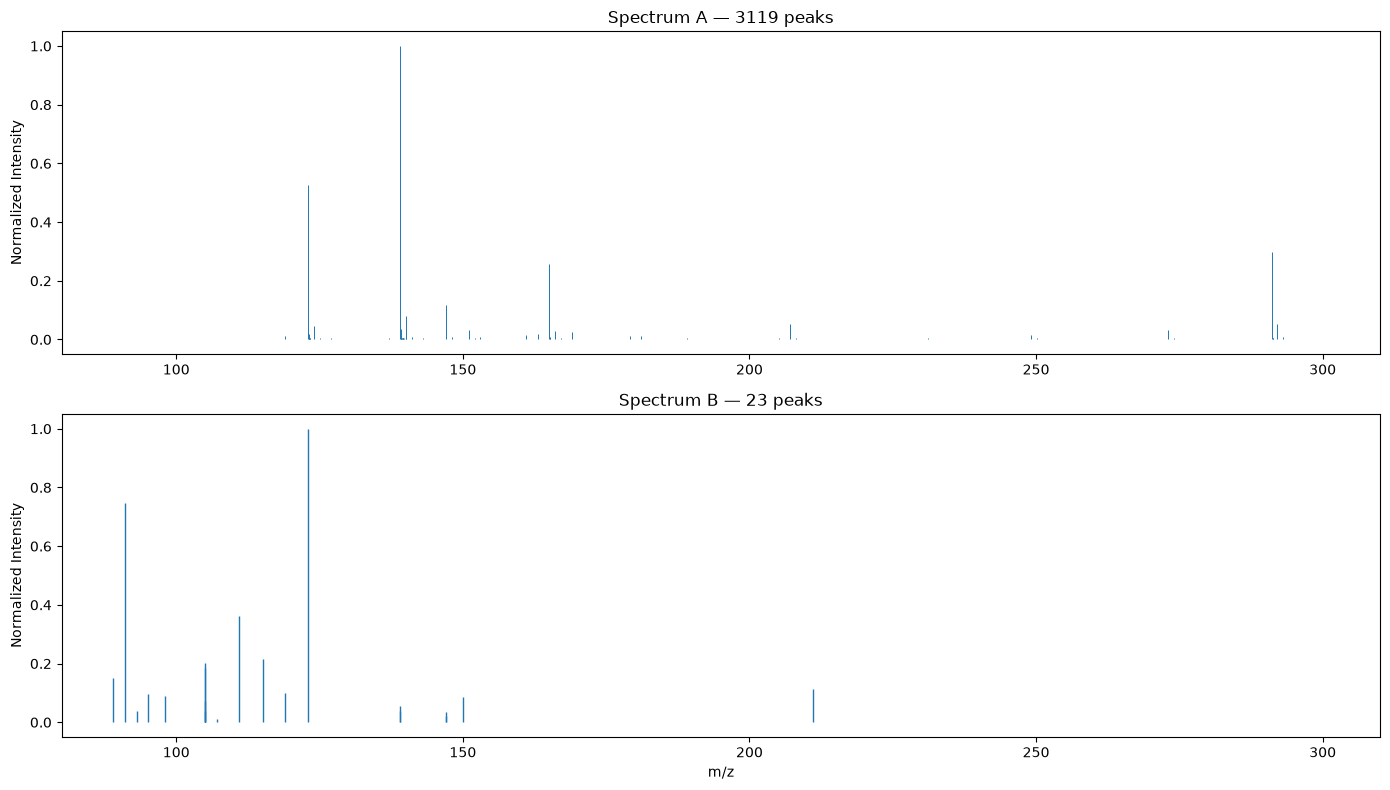

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].vlines(
    mz_a,
    0,
    intensity_a,
    linewidth=0.7
)

axes[0].set_title("Spectrum A — 3119 peaks")
axes[0].set_ylabel("Normalized Intensity")
axes[0].set_xlim(80, 310)

axes[1].vlines(
    mz_b,
    0,
    intensity_b,
    linewidth=1
)

axes[1].set_title("Spectrum B — 23 peaks")
axes[1].set_xlabel("m/z")
axes[1].set_ylabel("Normalized Intensity")
axes[1].set_xlim(80, 310)

plt.tight_layout()
plt.show()

In [20]:
def filter_peaks(mz, intensity, min_intensity=0.01):
    """
    Keep only peaks whose normalized intensity is
    at least min_intensity.
    """
    mask = intensity >= min_intensity

    return mz[mask], intensity[mask]


thresholds = [0, 0.001, 0.005, 0.01, 0.05, 0.10]

print("Peak counts after intensity filtering\n")

for threshold in thresholds:
    mz_filtered, intensity_filtered = filter_peaks(
        mz_a,
        intensity_a,
        min_intensity=threshold
    )

    print(
        f"Threshold {threshold:>5.3f}: "
        f"{len(mz_filtered):>5} peaks"
    )

Peak counts after intensity filtering

Threshold 0.000:  3119 peaks
Threshold 0.001:   142 peaks
Threshold 0.005:    41 peaks
Threshold 0.010:    22 peaks
Threshold 0.050:     8 peaks
Threshold 0.100:     5 peaks


In [21]:
print("\nSpectrum B\n")

for threshold in thresholds:
    mz_filtered, intensity_filtered = filter_peaks(
        mz_b,
        intensity_b,
        min_intensity=threshold
    )

    print(
        f"Threshold {threshold:>5.3f}: "
        f"{len(mz_filtered):>5} peaks"
    )


Spectrum B

Threshold 0.000:    23 peaks
Threshold 0.001:    23 peaks
Threshold 0.005:    23 peaks
Threshold 0.010:    23 peaks
Threshold 0.050:    16 peaks
Threshold 0.100:    10 peaks


In [22]:
def spectral_cosine_similarity(
    mz1,
    intensity1,
    mz2,
    intensity2,
    tolerance=0.01,
    min_intensity=0.0
):
    """
    Calculate cosine similarity between two MS/MS spectra.

    Peaks are matched one-to-one within the specified m/z tolerance.
    Unmatched peaks contribute to the denominator but not the numerator.
    """

    # Filter weak peaks
    mask1 = intensity1 >= min_intensity
    mask2 = intensity2 >= min_intensity

    mz1 = mz1[mask1]
    intensity1 = intensity1[mask1]

    mz2 = mz2[mask2]
    intensity2 = intensity2[mask2]

    # Store possible matches:
    # (m/z difference, index1, index2)
    possible_matches = []

    for i in range(len(mz1)):
        differences = np.abs(mz2 - mz1[i])

        for j in np.where(differences <= tolerance)[0]:
            possible_matches.append(
                (differences[j], i, j)
            )

    # Closest matches first
    possible_matches.sort(key=lambda x: x[0])

    used_1 = set()
    used_2 = set()

    matched_pairs = []

    for difference, i, j in possible_matches:

        if i in used_1 or j in used_2:
            continue

        used_1.add(i)
        used_2.add(j)

        matched_pairs.append((i, j, difference))

    # Cosine numerator
    numerator = sum(
        intensity1[i] * intensity2[j]
        for i, j, _ in matched_pairs
    )

    # Include ALL peaks in denominator
    denominator = np.sqrt(
        np.sum(intensity1 ** 2) *
        np.sum(intensity2 ** 2)
    )

    if denominator == 0:
        return 0.0, matched_pairs

    similarity = numerator / denominator

    return similarity, matched_pairs

In [23]:
thresholds = [0, 0.001, 0.005, 0.01, 0.05, 0.10]

print("Spectrum A vs Spectrum B\n")

for threshold in thresholds:

    similarity, matched_pairs = spectral_cosine_similarity(
        mz_a,
        intensity_a,
        mz_b,
        intensity_b,
        tolerance=0.01,
        min_intensity=threshold
    )

    print(
        f"Threshold: {threshold:>5.3f} | "
        f"A peaks: {np.sum(intensity_a >= threshold):>4} | "
        f"B peaks: {np.sum(intensity_b >= threshold):>3} | "
        f"Matches: {len(matched_pairs):>3} | "
        f"Similarity: {similarity:.4f}"
    )

Spectrum A vs Spectrum B

Threshold: 0.000 | A peaks: 3119 | B peaks:  23 | Matches:   7 | Similarity: 0.3308
Threshold: 0.001 | A peaks:  142 | B peaks:  23 | Matches:   5 | Similarity: 0.3307
Threshold: 0.005 | A peaks:   41 | B peaks:  23 | Matches:   4 | Similarity: 0.3308
Threshold: 0.010 | A peaks:   22 | B peaks:  23 | Matches:   4 | Similarity: 0.3309
Threshold: 0.050 | A peaks:    8 | B peaks:  16 | Matches:   1 | Similarity: 0.3081
Threshold: 0.100 | A peaks:    5 | B peaks:  10 | Matches:   1 | Similarity: 0.3128


In [24]:
# Find a different molecule with the same experimental conditions

target_smiles = same_molecule.iloc[0]["normalized_smiles"]

different_molecule = train_file[
    (train_file["ionization_mode"] == "positive") &
    (train_file["adduct"] == "[M+H]+") &
    (train_file["precursor_mz"].round(4) == 291.0900) &
    (train_file["normalized_smiles"] != target_smiles)
].reset_index(drop=True)

print("Different-molecule spectra found:", len(different_molecule))

display(
    different_molecule[
        [
            "normalized_smiles",
            "precursor_mz",
            "adduct",
            "num_peaks"
        ]
    ].head(10)
)

# Select one different molecule
spectrum_c = different_molecule.iloc[0]

mz_c = np.asarray(spectrum_c["ms2_mzs"])
intensity_c = np.asarray(
    spectrum_c["ms2_normalized_intensities"]
)

# Compare Spectrum A (target molecule) against Spectrum C
similarity_diff, matched_diff = spectral_cosine_similarity(
    mz_a,
    intensity_a,
    mz_c,
    intensity_c,
    tolerance=0.01,
    min_intensity=0.01
)

print("\nTarget molecule:")
print(target_smiles)

print("\nDifferent molecule:")
print(spectrum_c["normalized_smiles"])

print("\nSpectrum A peaks:", len(mz_a))
print("Spectrum C peaks:", len(mz_c))
print("Matched peaks:", len(matched_diff))
print("Similarity:", round(similarity_diff, 4))

Different-molecule spectra found: 21


,normalized_smiles,precursor_mz,adduct,num_peaks
0,CN1CCN(C(=O)c2ccc(Cl)o2)c2ccccc2C1,291.09,[M+H]+,970
1,CN1CCN(C(=O)c2ccc(Cl)o2)c2ccccc2C1,291.09,[M+H]+,2067
2,CN1CCN(C(=O)c2ccc(Cl)o2)c2ccccc2C1,291.09,[M+H]+,1013
3,CN1CCN(C(=O)c2ccc(Cl)o2)c2ccccc2C1,291.09,[M+H]+,724
4,COc1cc(Cl)cc(CC(=O)Nc2cnccc2C)c1,291.09,[M+H]+,342
5,COc1cc(Cl)cc(CC(=O)Nc2cnccc2C)c1,291.09,[M+H]+,231
6,COc1cc(Cl)cc(CC(=O)Nc2cnccc2C)c1,291.09,[M+H]+,225
7,CN(C)C(=O)Nc1ccc(Oc2ccc(Cl)cc2)cc1,291.09,[M+H]+,12
8,CN(C)C(=O)Nc1ccc(Oc2ccc(Cl)cc2)cc1,291.09,[M+H]+,12
9,CN(C)C(=O)Nc1ccc(Oc2ccc(Cl)cc2)cc1,291.09,[M+H]+,9



Target molecule:
Oc1cc(O)c2c(c1)OC(c1ccc(O)c(O)c1)C(O)C2

Different molecule:
CN1CCN(C(=O)c2ccc(Cl)o2)c2ccccc2C1

Spectrum A peaks: 3119
Spectrum C peaks: 970
Matched peaks: 0
Similarity: 0.0


In [25]:
# Compare the query spectrum against multiple
# same-molecule and different-molecule spectra

QUERY_MIN_INTENSITY = 0.01
TOLERANCE = 0.01
N = 20

# --------------------------------------------------
# Prepare query spectrum
# --------------------------------------------------

query_mz, query_intensity = filter_peaks(
    mz_a,
    intensity_a,
    min_intensity=QUERY_MIN_INTENSITY
)

# --------------------------------------------------
# Same-molecule candidates
# --------------------------------------------------

same_candidates = comparable_same_precursor[
    comparable_same_precursor.index != comparable_same_precursor.index[0]
].head(N)

same_scores = []

for _, candidate in same_candidates.iterrows():

    candidate_mz = np.asarray(candidate["ms2_mzs"])
    candidate_intensity = np.asarray(
        candidate["ms2_normalized_intensities"]
    )

    score, matches = spectral_cosine_similarity(
        query_mz,
        query_intensity,
        candidate_mz,
        candidate_intensity,
        tolerance=TOLERANCE,
        min_intensity=QUERY_MIN_INTENSITY
    )

    same_scores.append(score)


# --------------------------------------------------
# Different-molecule candidates
# --------------------------------------------------

different_candidates = train_file[
    (train_file["ionization_mode"] == "positive") &
    (train_file["adduct"] == "[M+H]+") &
    (train_file["precursor_mz"].round(4) == 291.0900) &
    (train_file["normalized_smiles"] != target_smiles)
].head(N)

different_scores = []

for _, candidate in different_candidates.iterrows():

    candidate_mz = np.asarray(candidate["ms2_mzs"])
    candidate_intensity = np.asarray(
        candidate["ms2_normalized_intensities"]
    )

    score, matches = spectral_cosine_similarity(
        query_mz,
        query_intensity,
        candidate_mz,
        candidate_intensity,
        tolerance=TOLERANCE,
        min_intensity=QUERY_MIN_INTENSITY
    )

    different_scores.append(score)


# --------------------------------------------------
# Results
# --------------------------------------------------

print("Same-molecule scores:")
print(np.round(same_scores, 4))

print("\nDifferent-molecule scores:")
print(np.round(different_scores, 4))

print("\nSummary")
print("-" * 40)

print(
    f"Same molecule      → "
    f"mean = {np.mean(same_scores):.4f}, "
    f"max = {np.max(same_scores):.4f}, "
    f"min = {np.min(same_scores):.4f}"
)

print(
    f"Different molecule → "
    f"mean = {np.mean(different_scores):.4f}, "
    f"max = {np.max(different_scores):.4f}, "
    f"min = {np.min(different_scores):.4f}"
)

Same-molecule scores:
[0.3309 0.7251 0.5226 0.5103 0.8884 0.8329 0.783  0.     0.7189 0.0169
 0.     0.     0.7828 0.375  0.     0.3621 0.235  0.2097 0.7057 0.2971]

Different-molecule scores:
[0.     0.0486 0.0989 0.0008 0.1668 0.0053 0.     0.     0.245  0.2321
 0.     0.0638 0.0419 0.0003 0.     0.     0.237  0.0263 0.     0.0752]

Summary
----------------------------------------
Same molecule      → mean = 0.4148, max = 0.8884, min = 0.0000
Different molecule → mean = 0.0621, max = 0.2450, min = 0.0000


In [26]:
# Inspect the competition test set

test_file = pd.read_parquet(
    "../data/raw/test.parquet"
)

print("Test shape:", test_file.shape)

print("\nTest columns:")
print(test_file.columns.tolist())

print("\nTest dtypes:")
print(test_file.dtypes)

print("\nFirst test row:")
display(test_file.iloc[0])

Test shape: (1213, 12)

Test columns:
['molecule_id', 'spectrum_id', 'ms2_mzs', 'ms2_normalized_intensities', 'base_peak_intensity', 'adduct', 'ionization_mode', 'instrument_type', 'precursor_mz', 'collision_energy_orig', 'collision_energy_ev', 'collision_energy_orig_units']

Test dtypes:
molecule_id                        str
spectrum_id                        str
ms2_mzs                         object
ms2_normalized_intensities      object
base_peak_intensity            float64
adduct                             str
ionization_mode                    str
instrument_type                    str
precursor_mz                   float64
collision_energy_orig              str
collision_energy_ev             object
collision_energy_orig_units        str
dtype: object

First test row:


molecule_id                                                             m_005e53
spectrum_id                                                           s_4d19d522
ms2_mzs                        [67.0414, 73.0074, 74.0142, 74.0174, 75.0238, ...
ms2_normalized_intensities     [0.0016501163269310492, 0.0004909040749095276,...
base_peak_intensity                                                    2711324.0
adduct                                                                    [M+H]+
ionization_mode                                                         positive
instrument_type                                                          timsTOF
precursor_mz                                                            375.0709
collision_energy_orig                                                   20,40,60
collision_energy_ev                                           [20.0, 40.0, 60.0]
collision_energy_orig_units                                                   eV
Name: 0, dtype: object

In [27]:
print("\nTrain columns:")
print(train_file.columns.tolist())

print("\nTest columns:")
print(test_file.columns.tolist())

print("\nColumns only in train:")
print(sorted(set(train_file.columns) - set(test_file.columns)))

print("\nColumns only in test:")
print(sorted(set(test_file.columns) - set(train_file.columns)))


Train columns:
['ingest_lib', 'normalized_smiles', 'inchikey', 'inchikey14', 'molecular_formula', 'ionization_mode', 'instrument_type', 'adduct', 'adduct_orig', 'precursor_mz', 'precursor_error_ppm', 'ms2_mzs', 'ms2_normalized_intensities', 'num_peaks', 'base_peak_intensity', 'collision_energy_ev', 'collision_energy_orig', 'collision_energy_orig_units']

Test columns:
['molecule_id', 'spectrum_id', 'ms2_mzs', 'ms2_normalized_intensities', 'base_peak_intensity', 'adduct', 'ionization_mode', 'instrument_type', 'precursor_mz', 'collision_energy_orig', 'collision_energy_ev', 'collision_energy_orig_units']

Columns only in train:
['adduct_orig', 'inchikey', 'inchikey14', 'ingest_lib', 'molecular_formula', 'normalized_smiles', 'num_peaks', 'precursor_error_ppm']

Columns only in test:
['molecule_id', 'spectrum_id']


In [28]:
submission = pd.read_csv(
    "../data/raw/sample_submission.csv"
)

print("Submission shape:", submission.shape)

print("\nSubmission columns:")
print(submission.columns.tolist())

display(submission.head())

Submission shape: (400, 2)

Submission columns:
['molecule_id', 'smiles']


,molecule_id,smiles
0,m_005e53,CCO;CCO;CCO;CCO;CCO;CCO;CCO;CCO;CCO;CCO;CCO;CC...
1,m_006153,CCO;CCO;CCO;CCO;CCO;CCO;CCO;CCO;CCO;CCO;CCO;CC...
2,m_00b5aa,CCO;CCO;CCO;CCO;CCO;CCO;CCO;CCO;CCO;CCO;CCO;CC...
3,m_01e922,CCO;CCO;CCO;CCO;CCO;CCO;CCO;CCO;CCO;CCO;CCO;CC...
4,m_0259d4,CCO;CCO;CCO;CCO;CCO;CCO;CCO;CCO;CCO;CCO;CCO;CC...


In [29]:
print("Test rows:", len(test_file))

print(
    "Unique molecule IDs:",
    test_file["molecule_id"].nunique()
)

print(
    "Unique spectrum IDs:",
    test_file["spectrum_id"].nunique()
)

print("\nSpectra per molecule:")
print(
    test_file["molecule_id"]
    .value_counts()
    .describe()
)

print("\nMost common molecule IDs:")
display(
    test_file["molecule_id"]
    .value_counts()
    .head(20)
)

Test rows: 1213
Unique molecule IDs: 400
Unique spectrum IDs: 1213

Spectra per molecule:
count    400.000000
mean       3.032500
std        1.382469
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        9.000000
Name: count, dtype: float64

Most common molecule IDs:


molecule_id
m_e8359d    9
m_b8415b    8
m_c63e89    8
m_0259d4    7
m_97cca9    7
m_006153    6
m_068354    6
m_20b8f2    6
m_3ce578    6
m_5c710b    6
m_6105c1    6
m_6ebcf9    6
m_75100f    6
m_83ac87    6
m_9068e1    6
m_b51204    6
m_c567df    6
m_e2993b    6
m_f866a0    6
m_0f05e7    5
Name: count, dtype: int64

In [30]:
# Summarize experimental conditions for each test molecule

test_summary = (
    test_file
    .groupby("molecule_id")
    .agg(
        n_spectra=("spectrum_id", "count"),
        n_adducts=("adduct", "nunique"),
        n_ionization=("ionization_mode", "nunique"),
        n_instruments=("instrument_type", "nunique"),
        min_precursor=("precursor_mz", "min"),
        max_precursor=("precursor_mz", "max"),
    )
    .sort_values("n_spectra", ascending=False)
)

display(test_summary.head(20))

,n_spectra,n_adducts,n_ionization,n_instruments,min_precursor,max_precursor
molecule_id,,,,,,
m_e8359d,9,3,2,1,331.1455,355.1424
m_c63e89,8,2,2,1,345.1428,347.1569
m_b8415b,8,3,2,1,359.0518,405.0570
m_0259d4,7,2,2,1,340.1775,384.1681
m_97cca9,7,2,2,1,313.1670,315.1824
m_3ce578,6,2,2,1,393.1130,395.1278
m_20b8f2,6,2,2,1,271.1205,273.1353
m_e2993b,6,3,2,1,268.1018,292.0985
m_c567df,6,2,1,1,416.1340,438.1152


In [31]:
print("Number of test molecules with:")

print(
    "\nMultiple adducts:",
    (test_summary["n_adducts"] > 1).sum()
)

print(
    "Multiple ionization modes:",
    (test_summary["n_ionization"] > 1).sum()
)

print(
    "Multiple instruments:",
    (test_summary["n_instruments"] > 1).sum()
)

print(
    "\nSpectra per molecule distribution:"
)

print(
    test_summary["n_spectra"].value_counts().sort_index()
)

Number of test molecules with:

Multiple adducts: 108
Multiple ionization modes: 97
Multiple instruments: 0

Spectra per molecule distribution:
n_spectra
1     55
2     97
3     99
4    106
5     24
6     14
7      2
8      2
9      1
Name: count, dtype: int64


In [32]:
# Inspect one complete unknown test molecule

test_molecule_id = "m_e8359d"

test_group = test_file[
    test_file["molecule_id"] == test_molecule_id
].reset_index(drop=True)

print("Molecule ID:", test_molecule_id)
print("Number of spectra:", len(test_group))

display(
    test_group[
        [
            "spectrum_id",
            "adduct",
            "ionization_mode",
            "instrument_type",
            "precursor_mz",
            "collision_energy_ev",
        ]
    ]
)

Molecule ID: m_e8359d
Number of spectra: 9


,spectrum_id,adduct,ionization_mode,instrument_type,precursor_mz,collision_energy_ev
0,s_24a837e2,[M-H]-,negative,timsTOF,331.1456,[40.0]
1,s_3316b7f6,[M+Na]+,positive,timsTOF,355.1424,[40.0]
2,s_3b5f4756,[M+Na]+,positive,timsTOF,355.1424,"[20.0, 40.0, 60.0]"
3,s_7f36169e,[M+H]+,positive,timsTOF,333.1605,[60.0]
4,s_9391385c,[M+H]+,positive,timsTOF,333.1605,[20.0]
5,s_a74f69f3,[M+H]+,positive,timsTOF,333.1605,"[20.0, 40.0, 60.0]"
6,s_b6512565,[M+Na]+,positive,timsTOF,355.1423,[60.0]
7,s_bbf0eaa6,[M-H]-,negative,timsTOF,331.1455,[60.0]
8,s_c82d61bb,[M+H]+,positive,timsTOF,333.1605,[40.0]


In [33]:
print("Peak counts:")

display(
    test_group[
        [
            "spectrum_id",
            "precursor_mz",
            "adduct",
            "ionization_mode",
            "ms2_mzs",
            "ms2_normalized_intensities",
        ]
    ].assign(
        num_peaks=lambda x: x["ms2_mzs"].apply(len)
    )[
        [
            "spectrum_id",
            "precursor_mz",
            "adduct",
            "ionization_mode",
            "num_peaks",
        ]
    ]
)

Peak counts:


,spectrum_id,precursor_mz,adduct,ionization_mode,num_peaks
0,s_24a837e2,331.1456,[M-H]-,negative,31
1,s_3316b7f6,355.1424,[M+Na]+,positive,107
2,s_3b5f4756,355.1424,[M+Na]+,positive,227
3,s_7f36169e,333.1605,[M+H]+,positive,501
4,s_9391385c,333.1605,[M+H]+,positive,422
5,s_a74f69f3,333.1605,[M+H]+,positive,856
6,s_b6512565,355.1423,[M+Na]+,positive,79
7,s_bbf0eaa6,331.1455,[M-H]-,negative,16
8,s_c82d61bb,333.1605,[M+H]+,positive,573


In [35]:
# Select a real test spectrum from m_e8359d

test_group = test_file[
    test_file["molecule_id"] == "m_e8359d"
].copy()

query_candidates = test_group[
    (test_group["adduct"] == "[M+H]+") &
    (test_group["ionization_mode"] == "positive")
].copy()

display(
    query_candidates[
        [
            "spectrum_id",
            "adduct",
            "ionization_mode",
            "precursor_mz",
            "collision_energy_ev"
        ]
    ]
)

,spectrum_id,adduct,ionization_mode,precursor_mz,collision_energy_ev
1065,s_7f36169e,[M+H]+,positive,333.1605,[60.0]
1066,s_9391385c,[M+H]+,positive,333.1605,[20.0]
1067,s_a74f69f3,[M+H]+,positive,333.1605,"[20.0, 40.0, 60.0]"
1070,s_c82d61bb,[M+H]+,positive,333.1605,[40.0]


In [36]:
query = query_candidates.iloc[0]

query_mz = np.asarray(query["ms2_mzs"])
query_intensity = np.asarray(
    query["ms2_normalized_intensities"]
)

print("Query spectrum")
print("--------------")
print("Molecule ID:", query["molecule_id"])
print("Spectrum ID:", query["spectrum_id"])
print("Adduct:", query["adduct"])
print("Ionization:", query["ionization_mode"])
print("Precursor m/z:", query["precursor_mz"])
print("Number of peaks:", len(query_mz))
print("Collision energy:", query["collision_energy_ev"])

Query spectrum
--------------
Molecule ID: m_e8359d
Spectrum ID: s_7f36169e
Adduct: [M+H]+
Ionization: positive
Precursor m/z: 333.1605
Number of peaks: 501
Collision energy: [60.]


In [37]:
# --------------------------------------------------
# Filter training spectra using known query metadata
# --------------------------------------------------

precursor_tolerance = 0.02

candidates = train_file[
    (train_file["adduct"] == query["adduct"]) &
    (train_file["ionization_mode"] == query["ionization_mode"]) &
    (
        np.abs(
            train_file["precursor_mz"] -
            query["precursor_mz"]
        ) <= precursor_tolerance
    )
].copy()

print("Candidate spectra:", len(candidates))

print(
    "Candidate molecules:",
    candidates["normalized_smiles"].nunique()
)

print("\nPrecursor m/z range:")
print(
    candidates["precursor_mz"].min(),
    "→",
    candidates["precursor_mz"].max()
)

print("\nCandidate adducts:")
print(candidates["adduct"].value_counts())

print("\nCandidate ionization:")
print(candidates["ionization_mode"].value_counts())

Candidate spectra: 3057
Candidate molecules: 728

Precursor m/z range:
333.1409 → 333.1805

Candidate adducts:
adduct
[M+H]+    3057
Name: count, dtype: int64

Candidate ionization:
ionization_mode
positive    3057
Name: count, dtype: int64


In [38]:
def spectral_cosine_similarity_fast(
    mz1,
    intensity1,
    mz2,
    intensity2,
    tolerance=0.01,
    min_intensity=0.01,
):
    """
    Faster one-to-one cosine similarity for MS/MS spectra.

    Uses binary search to find nearby m/z peaks instead of
    comparing every peak against every other peak.
    """

    # Filter weak peaks
    mz1, intensity1 = filter_peaks(
        mz1,
        intensity1,
        min_intensity
    )

    mz2, intensity2 = filter_peaks(
        mz2,
        intensity2,
        min_intensity
    )

    # Make sure peaks are sorted by m/z
    order1 = np.argsort(mz1)
    order2 = np.argsort(mz2)

    mz1 = mz1[order1]
    intensity1 = intensity1[order1]

    mz2 = mz2[order2]
    intensity2 = intensity2[order2]

    possible_matches = []

    # Find nearby peaks using binary search
    for i, mz_value in enumerate(mz1):

        left = np.searchsorted(
            mz2,
            mz_value - tolerance,
            side="left"
        )

        right = np.searchsorted(
            mz2,
            mz_value + tolerance,
            side="right"
        )

        for j in range(left, right):

            difference = abs(mz_value - mz2[j])

            possible_matches.append(
                (difference, i, j)
            )

    # Closest matches first
    possible_matches.sort(key=lambda x: x[0])

    used_1 = set()
    used_2 = set()

    numerator = 0.0

    for difference, i, j in possible_matches:

        if i in used_1 or j in used_2:
            continue

        used_1.add(i)
        used_2.add(j)

        numerator += intensity1[i] * intensity2[j]

    denominator = np.sqrt(
        np.sum(intensity1 ** 2)
        * np.sum(intensity2 ** 2)
    )

    if denominator == 0:
        return 0.0

    return numerator / denominator

In [39]:
old_score, _ = spectral_cosine_similarity(
    mz_a,
    intensity_a,
    mz_b,
    intensity_b,
    tolerance=0.01,
    min_intensity=0.01
)

new_score = spectral_cosine_similarity_fast(
    mz_a,
    intensity_a,
    mz_b,
    intensity_b,
    tolerance=0.01,
    min_intensity=0.01
)

print("Old score:", old_score)
print("New score:", new_score)

Old score: 0.3309026514876182
New score: 0.3309026514876182


In [40]:
results = []

for idx, candidate in candidates.iterrows():

    candidate_mz = np.asarray(candidate["ms2_mzs"])
    candidate_intensity = np.asarray(
        candidate["ms2_normalized_intensities"]
    )

    score = spectral_cosine_similarity_fast(
        query_mz,
        query_intensity,
        candidate_mz,
        candidate_intensity,
        tolerance=0.01,
        min_intensity=0.01
    )

    results.append({
        "index": idx,
        "score": score,
        "smiles": candidate["normalized_smiles"],
        "precursor_mz": candidate["precursor_mz"],
        "num_peaks": candidate["num_peaks"],
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "score",
    ascending=False
).reset_index(drop=True)

display(results_df.head(20))

,index,score,smiles,precursor_mz,num_peaks
0,347954,1.000000,O=C(Nc1c(-c2ccccc2)[nH]c2ccccc12)C1CC2CCC1O2,333.1605,501
1,347955,0.699551,O=C(Nc1c(-c2ccccc2)[nH]c2ccccc12)C1CC2CCC1O2,333.1605,573
2,347953,0.565185,O=C(Nc1c(-c2ccccc2)[nH]c2ccccc12)C1CC2CCC1O2,333.1605,856
3,931270,0.441387,CCCN1CCN(c2cnn(-c3ccccc3)c(=O)c2Cl)CC1,333.1488,728
4,267788,0.435320,O=C(NC1CCC(C(=O)N2CCSCC2)CC1)c1ccccc1,333.1636,113
5,1095664,0.397605,CN(C)C1(CNC(=O)C(=O)Nc2ccc(F)c(C#N)c2)CCCC1,333.1728,65
6,766214,0.365384,CCc1cccc(C(=O)N2CCc3c(cnn3-c3ccccc3)C2)n1,333.1719,358
7,381775,0.340936,CN(C)C1CN(C(=O)c2cc(-c3ccncc3)nc3ccccc23)C1,333.1717,509
8,970233,0.337332,O=C(NC1CCc2nnc(Cc3ccccc3)n2C1)c1ccccc1,333.1720,554
9,435345,0.325353,Cc1noc(C2CN(C(=O)c3noc4c3CCCC4)CC(C)O2)n1,333.1565,401


In [41]:
print(
    "Unique SMILES in top 20:",
    results_df.head(20)["smiles"].nunique()
)

display(
    results_df.head(20)[
        [
            "score",
            "precursor_mz",
            "num_peaks",
            "smiles"
        ]
    ]
)

Unique SMILES in top 20: 17


,score,precursor_mz,num_peaks,smiles
0,1.000000,333.1605,501,O=C(Nc1c(-c2ccccc2)[nH]c2ccccc12)C1CC2CCC1O2
1,0.699551,333.1605,573,O=C(Nc1c(-c2ccccc2)[nH]c2ccccc12)C1CC2CCC1O2
2,0.565185,333.1605,856,O=C(Nc1c(-c2ccccc2)[nH]c2ccccc12)C1CC2CCC1O2
3,0.441387,333.1488,728,CCCN1CCN(c2cnn(-c3ccccc3)c(=O)c2Cl)CC1
4,0.435320,333.1636,113,O=C(NC1CCC(C(=O)N2CCSCC2)CC1)c1ccccc1
5,0.397605,333.1728,65,CN(C)C1(CNC(=O)C(=O)Nc2ccc(F)c(C#N)c2)CCCC1
6,0.365384,333.1719,358,CCc1cccc(C(=O)N2CCc3c(cnn3-c3ccccc3)C2)n1
7,0.340936,333.1717,509,CN(C)C1CN(C(=O)c2cc(-c3ccncc3)nc3ccccc23)C1
8,0.337332,333.1720,554,O=C(NC1CCc2nnc(Cc3ccccc3)n2C1)c1ccccc1
9,0.325353,333.1565,401,Cc1noc(C2CN(C(=O)c3noc4c3CCCC4)CC(C)O2)n1


In [42]:
# Inspect the top-1 training match

top_result = results_df.iloc[0]
top_index = int(top_result["index"])

top_candidate = train_file.loc[top_index]

print("TOP TRAINING MATCH")
print("=" * 50)

print("Training row:", top_index)
print("SMILES:", top_candidate["normalized_smiles"])
print("Precursor m/z:", top_candidate["precursor_mz"])
print("Adduct:", top_candidate["adduct"])
print("Ionization:", top_candidate["ionization_mode"])
print("Instrument:", top_candidate["instrument_type"])
print("Number of peaks:", top_candidate["num_peaks"])

print("\nQuery")
print("-" * 50)
print("Precursor m/z:", query["precursor_mz"])
print("Adduct:", query["adduct"])
print("Ionization:", query["ionization_mode"])
print("Instrument:", query["instrument_type"])
print("Number of peaks:", len(query_mz))

# Extract candidate spectrum
candidate_mz = np.asarray(top_candidate["ms2_mzs"])
candidate_intensity = np.asarray(
    top_candidate["ms2_normalized_intensities"]
)

print("\nArray comparison")
print("-" * 50)

print(
    "Same number of peaks:",
    len(query_mz) == len(candidate_mz)
)

if len(query_mz) == len(candidate_mz):

    print(
        "m/z arrays exactly equal:",
        np.array_equal(query_mz, candidate_mz)
    )

    print(
        "Intensity arrays exactly equal:",
        np.array_equal(
            query_intensity,
            candidate_intensity
        )
    )

    print(
        "m/z arrays approximately equal:",
        np.allclose(
            query_mz,
            candidate_mz,
            atol=0.001
        )
    )

    print(
        "Intensity arrays approximately equal:",
        np.allclose(
            query_intensity,
            candidate_intensity,
            atol=1e-6
        )
    )

    print(
        "Maximum |m/z difference|:",
        np.max(np.abs(query_mz - candidate_mz))
    )

    print(
        "Maximum |intensity difference|:",
        np.max(
            np.abs(
                query_intensity -
                candidate_intensity
            )
        )
    )

TOP TRAINING MATCH
Training row: 347954
SMILES: O=C(Nc1c(-c2ccccc2)[nH]c2ccccc12)C1CC2CCC1O2
Precursor m/z: 333.1605
Adduct: [M+H]+
Ionization: positive
Instrument: timsTOF
Number of peaks: 501

Query
--------------------------------------------------
Precursor m/z: 333.1605
Adduct: [M+H]+
Ionization: positive
Instrument: timsTOF
Number of peaks: 501

Array comparison
--------------------------------------------------
Same number of peaks: True
m/z arrays exactly equal: True
Intensity arrays exactly equal: True
m/z arrays approximately equal: True
Intensity arrays approximately equal: True
Maximum |m/z difference|: 0.0
Maximum |intensity difference|: 0.0


In [43]:
# Test how often exact spectrum matches exist in the training data

def find_exact_spectrum_matches(query_row):
    """
    Find training spectra that are exactly identical
    to a test spectrum.

    We first narrow candidates using metadata and peak count,
    then compare the actual arrays.
    """

    query_mz = np.asarray(query_row["ms2_mzs"])
    query_intensity = np.asarray(
        query_row["ms2_normalized_intensities"]
    )

    candidates = train_file[
        (train_file["adduct"] == query_row["adduct"]) &
        (train_file["ionization_mode"] == query_row["ionization_mode"]) &
        (train_file["instrument_type"] == query_row["instrument_type"]) &
        (train_file["precursor_mz"] == query_row["precursor_mz"]) &
        (train_file["num_peaks"] == len(query_mz))
    ]

    matches = []

    for idx, candidate in candidates.iterrows():

        candidate_mz = np.asarray(candidate["ms2_mzs"])
        candidate_intensity = np.asarray(
            candidate["ms2_normalized_intensities"]
        )

        if (
            np.array_equal(query_mz, candidate_mz)
            and
            np.array_equal(
                query_intensity,
                candidate_intensity
            )
        ):
            matches.append(idx)

    return matches


# Test 20 spectra
sample_test = test_file.head(20)

exact_results = []

for _, query_row in sample_test.iterrows():

    matches = find_exact_spectrum_matches(query_row)

    exact_results.append({
        "molecule_id": query_row["molecule_id"],
        "spectrum_id": query_row["spectrum_id"],
        "n_exact_matches": len(matches),
        "matched_train_indices": matches,
    })


exact_results_df = pd.DataFrame(exact_results)

display(exact_results_df)

print(
    "\nTest spectra with an exact training match:",
    (exact_results_df["n_exact_matches"] > 0).sum(),
    "/",
    len(exact_results_df)
)

,molecule_id,spectrum_id,n_exact_matches,matched_train_indices
0,m_005e53,s_4d19d522,1,[725007]
1,m_005e53,s_5b6e28ff,1,[725008]
2,m_005e53,s_6e514292,1,[725006]
3,m_005e53,s_855ae19c,1,[725010]
4,m_006153,s_3c74e9fe,1,[69997]
5,m_006153,s_54245904,1,[70001]
6,m_006153,s_59a80abf,1,[69999]
7,m_006153,s_7151fa86,1,[69996]
8,m_006153,s_86472581,1,[70000]
9,m_006153,s_cb15f0ac,1,[69995]



Test spectra with an exact training match: 20 / 20


In [44]:
# ============================================================
# Exact spectral lookup for the complete test set
# ============================================================

def find_exact_spectrum_matches(query_row):
    """
    Find training spectra that are exactly identical
    to a test spectrum.
    """

    query_mz = np.asarray(query_row["ms2_mzs"])
    query_intensity = np.asarray(
        query_row["ms2_normalized_intensities"]
    )

    # First narrow the search using metadata
    candidates = train_file[
        (train_file["adduct"] == query_row["adduct"]) &
        (train_file["ionization_mode"] == query_row["ionization_mode"]) &
        (train_file["instrument_type"] == query_row["instrument_type"]) &
        (train_file["precursor_mz"] == query_row["precursor_mz"]) &
        (train_file["num_peaks"] == len(query_mz))
    ]

    matches = []

    for idx, candidate in candidates.iterrows():

        candidate_mz = np.asarray(candidate["ms2_mzs"])
        candidate_intensity = np.asarray(
            candidate["ms2_normalized_intensities"]
        )

        if (
            np.array_equal(query_mz, candidate_mz)
            and
            np.array_equal(
                query_intensity,
                candidate_intensity
            )
        ):
            matches.append(idx)

    return matches


exact_lookup_results = []

for i, query_row in test_file.iterrows():

    matches = find_exact_spectrum_matches(query_row)

    exact_lookup_results.append({
        "molecule_id": query_row["molecule_id"],
        "spectrum_id": query_row["spectrum_id"],
        "n_exact_matches": len(matches),
        "matched_train_indices": matches,
    })

    if (i + 1) % 100 == 0:
        print(f"Processed {i + 1}/{len(test_file)}")


exact_lookup_df = pd.DataFrame(exact_lookup_results)

print("\n" + "=" * 60)
print("EXACT MATCH RESULTS")
print("=" * 60)

print(
    "Test spectra:",
    len(exact_lookup_df)
)

print(
    "Spectra with exact match:",
    (exact_lookup_df["n_exact_matches"] > 0).sum()
)

print(
    "Spectra without exact match:",
    (exact_lookup_df["n_exact_matches"] == 0).sum()
)

print(
    "Match coverage:",
    f"{(exact_lookup_df['n_exact_matches'] > 0).mean() * 100:.2f}%"
)

Processed 100/1213
Processed 200/1213
Processed 300/1213
Processed 400/1213
Processed 500/1213
Processed 600/1213
Processed 700/1213
Processed 800/1213
Processed 900/1213
Processed 1000/1213
Processed 1100/1213
Processed 1200/1213

EXACT MATCH RESULTS
Test spectra: 1213
Spectra with exact match: 1213
Spectra without exact match: 0
Match coverage: 100.00%


In [45]:
# ============================================================
# Validate exact-match predictions at the molecule level
# ============================================================

# Get the SMILES associated with each exact training match
def get_matched_smiles(indices):
    return train_file.loc[indices[0], "normalized_smiles"]


exact_lookup_df["predicted_smiles"] = (
    exact_lookup_df["matched_train_indices"]
    .apply(get_matched_smiles)
)

# Check how many different predicted SMILES each
# test molecule_id receives
molecule_consistency = (
    exact_lookup_df
    .groupby("molecule_id")["predicted_smiles"]
    .nunique()
)

print("Test molecules:", len(molecule_consistency))

print(
    "Molecules with exactly one predicted SMILES:",
    (molecule_consistency == 1).sum()
)

print(
    "Molecules with conflicting predicted SMILES:",
    (molecule_consistency > 1).sum()
)

print("\nDistribution of number of predicted SMILES per molecule:")
print(molecule_consistency.value_counts().sort_index())

Test molecules: 400
Molecules with exactly one predicted SMILES: 400
Molecules with conflicting predicted SMILES: 0

Distribution of number of predicted SMILES per molecule:
predicted_smiles
1    400
Name: count, dtype: int64


In [46]:
# ============================================================
# Build final predictions
# ============================================================

predictions = (
    exact_lookup_df[
        ["molecule_id", "predicted_smiles"]
    ]
    .drop_duplicates("molecule_id")
    .rename(columns={
        "predicted_smiles": "smiles"
    })
)

print("Prediction rows:", len(predictions))

display(predictions.head(10))

Prediction rows: 400


,molecule_id,smiles
0,m_005e53,CN(Cc1ncccc1C(=O)O)CC1(c2ccc(Br)cc2)CC1
4,m_006153,COc1ccc(N2CC(C(=O)Nc3nncn3C3CC3)CC2=O)cc1
10,m_00b5aa,COc1ccnc(CN2CCOCC3(CCCC3)C2)c1OC
12,m_01e922,Cc1ccc(C(=O)OCC2CCCCC2)c(=O)[nH]1
15,m_0259d4,O=C(NCCCn1ccnc1)NCCc1coc(-c2ccccc2)n1
22,m_02d188,CC(=O)Nc1ccc(NCC(=O)NC(C)c2ccccc2)c(Cl)c1
24,m_0318b5,O=C(Nc1ccc(F)cc1)C(c1ccccc1)N1CCC(n2cccn2)CC1
27,m_043e86,OC(CNc1ncc(Cl)cc1F)CN1CCOCC1
30,m_050bf1,CCc1noc(COCC(=O)N2CC(C)(C)OC3COCC32)n1
32,m_05b52e,COc1ccc(Cl)cc1-c1cc(NC(=O)c2ccnc(C)n2)[nH]n1


In [47]:
# ============================================================
# Create submission in Kaggle's expected order
# ============================================================

submission_final = submission[["molecule_id"]].merge(
    predictions,
    on="molecule_id",
    how="left"
)

print("Submission shape:", submission_final.shape)

print(
    "Missing predictions:",
    submission_final["smiles"].isna().sum()
)

display(submission_final.head(10))

Submission shape: (400, 2)
Missing predictions: 0


,molecule_id,smiles
0,m_005e53,CN(Cc1ncccc1C(=O)O)CC1(c2ccc(Br)cc2)CC1
1,m_006153,COc1ccc(N2CC(C(=O)Nc3nncn3C3CC3)CC2=O)cc1
2,m_00b5aa,COc1ccnc(CN2CCOCC3(CCCC3)C2)c1OC
3,m_01e922,Cc1ccc(C(=O)OCC2CCCCC2)c(=O)[nH]1
4,m_0259d4,O=C(NCCCn1ccnc1)NCCc1coc(-c2ccccc2)n1
5,m_02d188,CC(=O)Nc1ccc(NCC(=O)NC(C)c2ccccc2)c(Cl)c1
6,m_0318b5,O=C(Nc1ccc(F)cc1)C(c1ccccc1)N1CCC(n2cccn2)CC1
7,m_043e86,OC(CNc1ncc(Cl)cc1F)CN1CCOCC1
8,m_050bf1,CCc1noc(COCC(=O)N2CC(C)(C)OC3COCC32)n1
9,m_05b52e,COc1ccc(Cl)cc1-c1cc(NC(=O)c2ccnc(C)n2)[nH]n1


In [48]:
# Save and verify the final submission

submission_path = "../outputs/submission_exact_lookup.csv"

submission_final.to_csv(
    submission_path,
    index=False
)

print("Saved:", submission_path)

# Verify the saved file
check = pd.read_csv(submission_path)

print("\nVerification")
print("=" * 40)
print("Shape:", check.shape)
print("Columns:", check.columns.tolist())
print("Missing SMILES:", check["smiles"].isna().sum())
print("Unique molecule IDs:", check["molecule_id"].nunique())

display(check.head(10))

Saved: ../outputs/submission_exact_lookup.csv

Verification
Shape: (400, 2)
Columns: ['molecule_id', 'smiles']
Missing SMILES: 0
Unique molecule IDs: 400


,molecule_id,smiles
0,m_005e53,CN(Cc1ncccc1C(=O)O)CC1(c2ccc(Br)cc2)CC1
1,m_006153,COc1ccc(N2CC(C(=O)Nc3nncn3C3CC3)CC2=O)cc1
2,m_00b5aa,COc1ccnc(CN2CCOCC3(CCCC3)C2)c1OC
3,m_01e922,Cc1ccc(C(=O)OCC2CCCCC2)c(=O)[nH]1
4,m_0259d4,O=C(NCCCn1ccnc1)NCCc1coc(-c2ccccc2)n1
5,m_02d188,CC(=O)Nc1ccc(NCC(=O)NC(C)c2ccccc2)c(Cl)c1
6,m_0318b5,O=C(Nc1ccc(F)cc1)C(c1ccccc1)N1CCC(n2cccn2)CC1
7,m_043e86,OC(CNc1ncc(Cl)cc1F)CN1CCOCC1
8,m_050bf1,CCc1noc(COCC(=O)N2CC(C)(C)OC3COCC32)n1
9,m_05b52e,COc1ccc(Cl)cc1-c1cc(NC(=O)c2ccnc(C)n2)[nH]n1
